<a href="https://colab.research.google.com/github/venkateshannabathina/icanseeyou_isro/blob/main/notebooks/03_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q lightkurve astropy astroquery

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 56.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 r

In [4]:
import lightkurve as lk

print(lk.__version__)

2.6.0


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [5]:
import lightkurve as lk

search_result = lk.search_lightcurve(
    "TIC 25155310",
    mission="TESS"
)

search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,25155310,0.0
1,TESS Sector 02,2018,SPOC,120,25155310,0.0
2,TESS Sector 03,2018,SPOC,120,25155310,0.0
3,TESS Sector 04,2018,SPOC,120,25155310,0.0
4,TESS Sector 05,2018,SPOC,120,25155310,0.0
5,TESS Sector 06,2018,SPOC,120,25155310,0.0
6,TESS Sector 07,2019,SPOC,120,25155310,0.0
7,TESS Sector 08,2019,SPOC,120,25155310,0.0
8,TESS Sector 09,2019,SPOC,120,25155310,0.0


In [6]:
lc = search_result[0].download()

print(lc)

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2966258808235  9.2627041e+03 ...  2.9971417e-02 -6.6027217e-02
1325.2980147804474  9.2711973e+03 ... -4.2239105e-04 -1.0025273e-01
 1325.299403680013  9.2906729e+03 ... -1.2138215e-03 -1.0391606e-01
1325.3007925795785  9.2628174e+03 ... -2.9799975e-03 -1.1566762e-01
1325.3021814792023  9.2777139e+03 ... -9.8572923e-03 -1.1535366e-01
 1325.303570378768  9.2604170e+03 ... -1.0768156e-02 -1.1588433e-01
1325.3049592783916  9.2684199e+03 ... -6.7567211e-03 -1.2002597e-01
1325.3063481780152  9.2672148e+03 ... -8.2860291e-03 -1.1578123e-01
 1325.307737077639  9.2526143e+03 ... -1.2014245e-02 -1.1912200e-01
               ...            ... ...            ...            ...
1353.1648095155513  9.2582285e+03 ... -1.6124731e-02 -5.4954281e-03
1353.1661984014393  9.2979814e+03 ... -1.2574126

In [7]:
lc_clean = (
    lc.remove_nans()
      .remove_outliers(sigma=5)
      .flatten(window_length=401)
      .normalize()
)

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

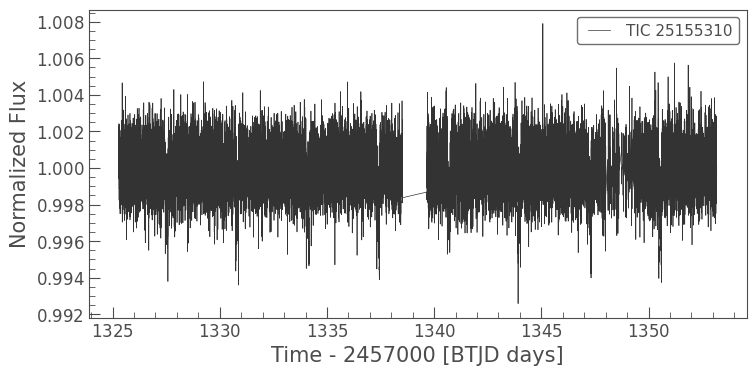

In [8]:
lc_clean.plot()

In [9]:
lc_clean.to_fits(
    "/content/drive/MyDrive/icanseeyou_isro/data/processed/tic25155310_clean.fits",
    overwrite=True
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/icanseeyou_isro/data/processed/tic25155310_clean.fits'

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
!ls -la /content/drive/MyDrive/icanseeyou_isro

total 26
drwx------ 2 root root 4096 Jun 22 02:14 data
drwx------ 2 root root 4096 Jun 22 02:14 .git
-rw------- 1 root root 2208 Jun 22 02:14 .gitignore
drwx------ 2 root root 4096 Jun 22 02:14 notebooks
-rw------- 1 root root  729 Jun 22 02:14 pyproject.toml
-rw------- 1 root root 1289 Jun 22 02:14 README.md
drwx------ 2 root root 4096 Jun 22 02:14 reports
-rw------- 1 root root  225 Jun 22 02:14 requirements.txt
drwx------ 2 root root 4096 Jun 22 02:14 src


In [12]:
!ls -la /content/drive/MyDrive/icanseeyou_isro/data

total 12
drwx------ 2 root root 4096 Jun 22 02:14 processed
drwx------ 2 root root 4096 Jun 22 02:14 raw
drwx------ 2 root root 4096 Jun 22 02:14 samples


In [13]:
import os

os.makedirs(
    "/content/drive/MyDrive/icanseeyou_isro/data/processed",
    exist_ok=True
)

In [14]:
!ls -la /content/drive/MyDrive/icanseeyou_isro/data

total 12
drwx------ 2 root root 4096 Jun 22 02:14 processed
drwx------ 2 root root 4096 Jun 22 02:14 raw
drwx------ 2 root root 4096 Jun 22 02:14 samples


In [15]:
lc_clean.to_fits(
    "/content/drive/MyDrive/icanseeyou_isro/data/processed/tic25155310_clean.fits",
    overwrite=True
)

In [16]:
!ls -la /content/drive/MyDrive/icanseeyou_isro/data/processed

total 720
-rw------- 1 root root      0 Jun 22 02:14 .gitkeep
-rw------- 1 root root 737280 Jun 22 02:57 tic25155310_clean.fits
